In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#3a3d4d',
    'axes.labelcolor'  : '#c9ccd6',
    'text.color'       : '#c9ccd6',
    'xtick.color'      : '#8b8fa8',
    'ytick.color'      : '#8b8fa8',
    'grid.color'       : '#2a2d3a',
    'grid.alpha'       : 0.5,
})

ACCENT = ['#4e8ef7','#f76e6e','#56d98e','#f7c948',
          '#b48ef7','#f7914e','#4ec9f7','#f74e8e']
SAVE   = '/tmp/agro_eda/'

import os
os.makedirs(SAVE, exist_ok=True)

df = pd.read_csv('/Volumes/weather/weather15/up15/agro_up_clean.csv', low_memory=False)
df['date']  = pd.to_datetime(df['date'], errors='coerce')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

TEMP_COLS  = [c for c in ['temp_mean','temp_max','temp_min'] if c in df.columns]
HUM_COLS   = [c for c in ['humidity_mean','dew_mean'] if c in df.columns]
RAIN_COLS  = [c for c in ['precip_total','precip_max','rain_occurred'] if c in df.columns]
WIND_COLS  = [c for c in ['wind_mean_10m','wind_max_10m','wind_mean_100m','wind_max_100m','wind_std_100m','wind_gusts_max'] if c in df.columns]
CLOUD_COLS = [c for c in ['cloud_mean','cloud_low_mean','cloud_mid_mean','cloud_high_mean'] if c in df.columns]
PRESS_COLS = [c for c in ['pressure_mean','surface_pressure_mean'] if c in df.columns]

ALL_NUMERIC = TEMP_COLS + HUM_COLS + RAIN_COLS + WIND_COLS + CLOUD_COLS + PRESS_COLS

print("=" * 60)
print("AG4P-4 | STEP 1 - Column Groups Identified")
print("=" * 60)
print("  Temperature :", TEMP_COLS)
print("  Humidity    :", HUM_COLS)
print("  Rainfall    :", RAIN_COLS)
print("  Wind        :", WIND_COLS)
print("  Cloud       :", CLOUD_COLS)
print("  Pressure    :", PRESS_COLS)
print("  Total cols  :", len(ALL_NUMERIC))
print("  Shape       :", df.shape)

AG4P-4 | STEP 1 - Column Groups Identified
  Temperature : ['temp_mean', 'temp_max', 'temp_min']
  Humidity    : ['humidity_mean', 'dew_mean']
  Rainfall    : ['precip_total', 'precip_max', 'rain_occurred']
  Wind        : ['wind_mean_10m', 'wind_max_10m', 'wind_mean_100m', 'wind_max_100m', 'wind_std_100m', 'wind_gusts_max']
  Cloud       : ['cloud_mean', 'cloud_low_mean', 'cloud_mid_mean', 'cloud_high_mean']
  Pressure    : ['pressure_mean', 'surface_pressure_mean']
  Total cols  : 20
  Shape       : (258200, 28)


Descriptive Statistics

In [0]:
print("=" * 60)
print("AG4P-4 | STEP 2 - Descriptive Statistics")
print("=" * 60)

stats = df[ALL_NUMERIC].describe().T
stats['skewness'] = df[ALL_NUMERIC].skew().round(3)
stats['kurtosis'] = df[ALL_NUMERIC].kurt().round(3)
stats['skew_flag'] = stats['skewness'].apply(
    lambda x: 'HIGH SKEW' if abs(x) > 2
              else 'moderate'  if abs(x) > 1
              else 'normal'
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 130)
pd.set_option('display.float_format', '{:.3f}'.format)

print(stats[['mean','std','min','50%','max','skewness','skew_flag']].to_string())

print("\n  KEY OBSERVATIONS:")
if 'temp_mean' in df.columns:
    print("  Temp mean     :", round(df['temp_mean'].mean(), 1), "C",
          "| range", round(df['temp_mean'].min(), 1),
          "to", round(df['temp_mean'].max(), 1), "C")

if 'precip_total' in df.columns:
    zero_rain = round((df['precip_total'] == 0).mean() * 100, 1)
    print("  Zero rain days:", zero_rain, "% -- zero-inflated, important for PS1")

if 'wind_mean_100m' in df.columns:
    print("  Wind 100m mean:", round(df['wind_mean_100m'].mean(), 2), "km/h (PS3 energy signal)")

AG4P-4 | STEP 2 - Descriptive Statistics
                          mean    std     min      50%      max  skewness  skew_flag
temp_mean               24.671  6.318   4.929   26.473   40.192    -0.427     normal
temp_max                30.272  6.084  10.896   30.957   46.965    -0.146     normal
temp_min                19.478  6.815   0.833   21.267   34.828    -0.445     normal
humidity_mean           66.190 18.140  11.299   70.225   98.794    -0.764     normal
dew_mean                16.649  6.633  -7.147   15.764   27.746    -0.031     normal
precip_total             2.878  8.264   0.000    0.000  304.700     7.795  HIGH SKEW
precip_max               0.855  2.065   0.000    0.000  102.600     5.942  HIGH SKEW
rain_occurred            0.394  0.489   0.000    0.000    1.000     0.436     normal
wind_mean_10m            9.048  3.533   1.532    8.366   37.357     1.228   moderate
wind_max_10m            14.302  5.198   2.969   13.325   54.731     0.935     normal
wind_mean_100m          

Histogram Grid

AG4P-4 | STEP 3 - Distribution Histograms


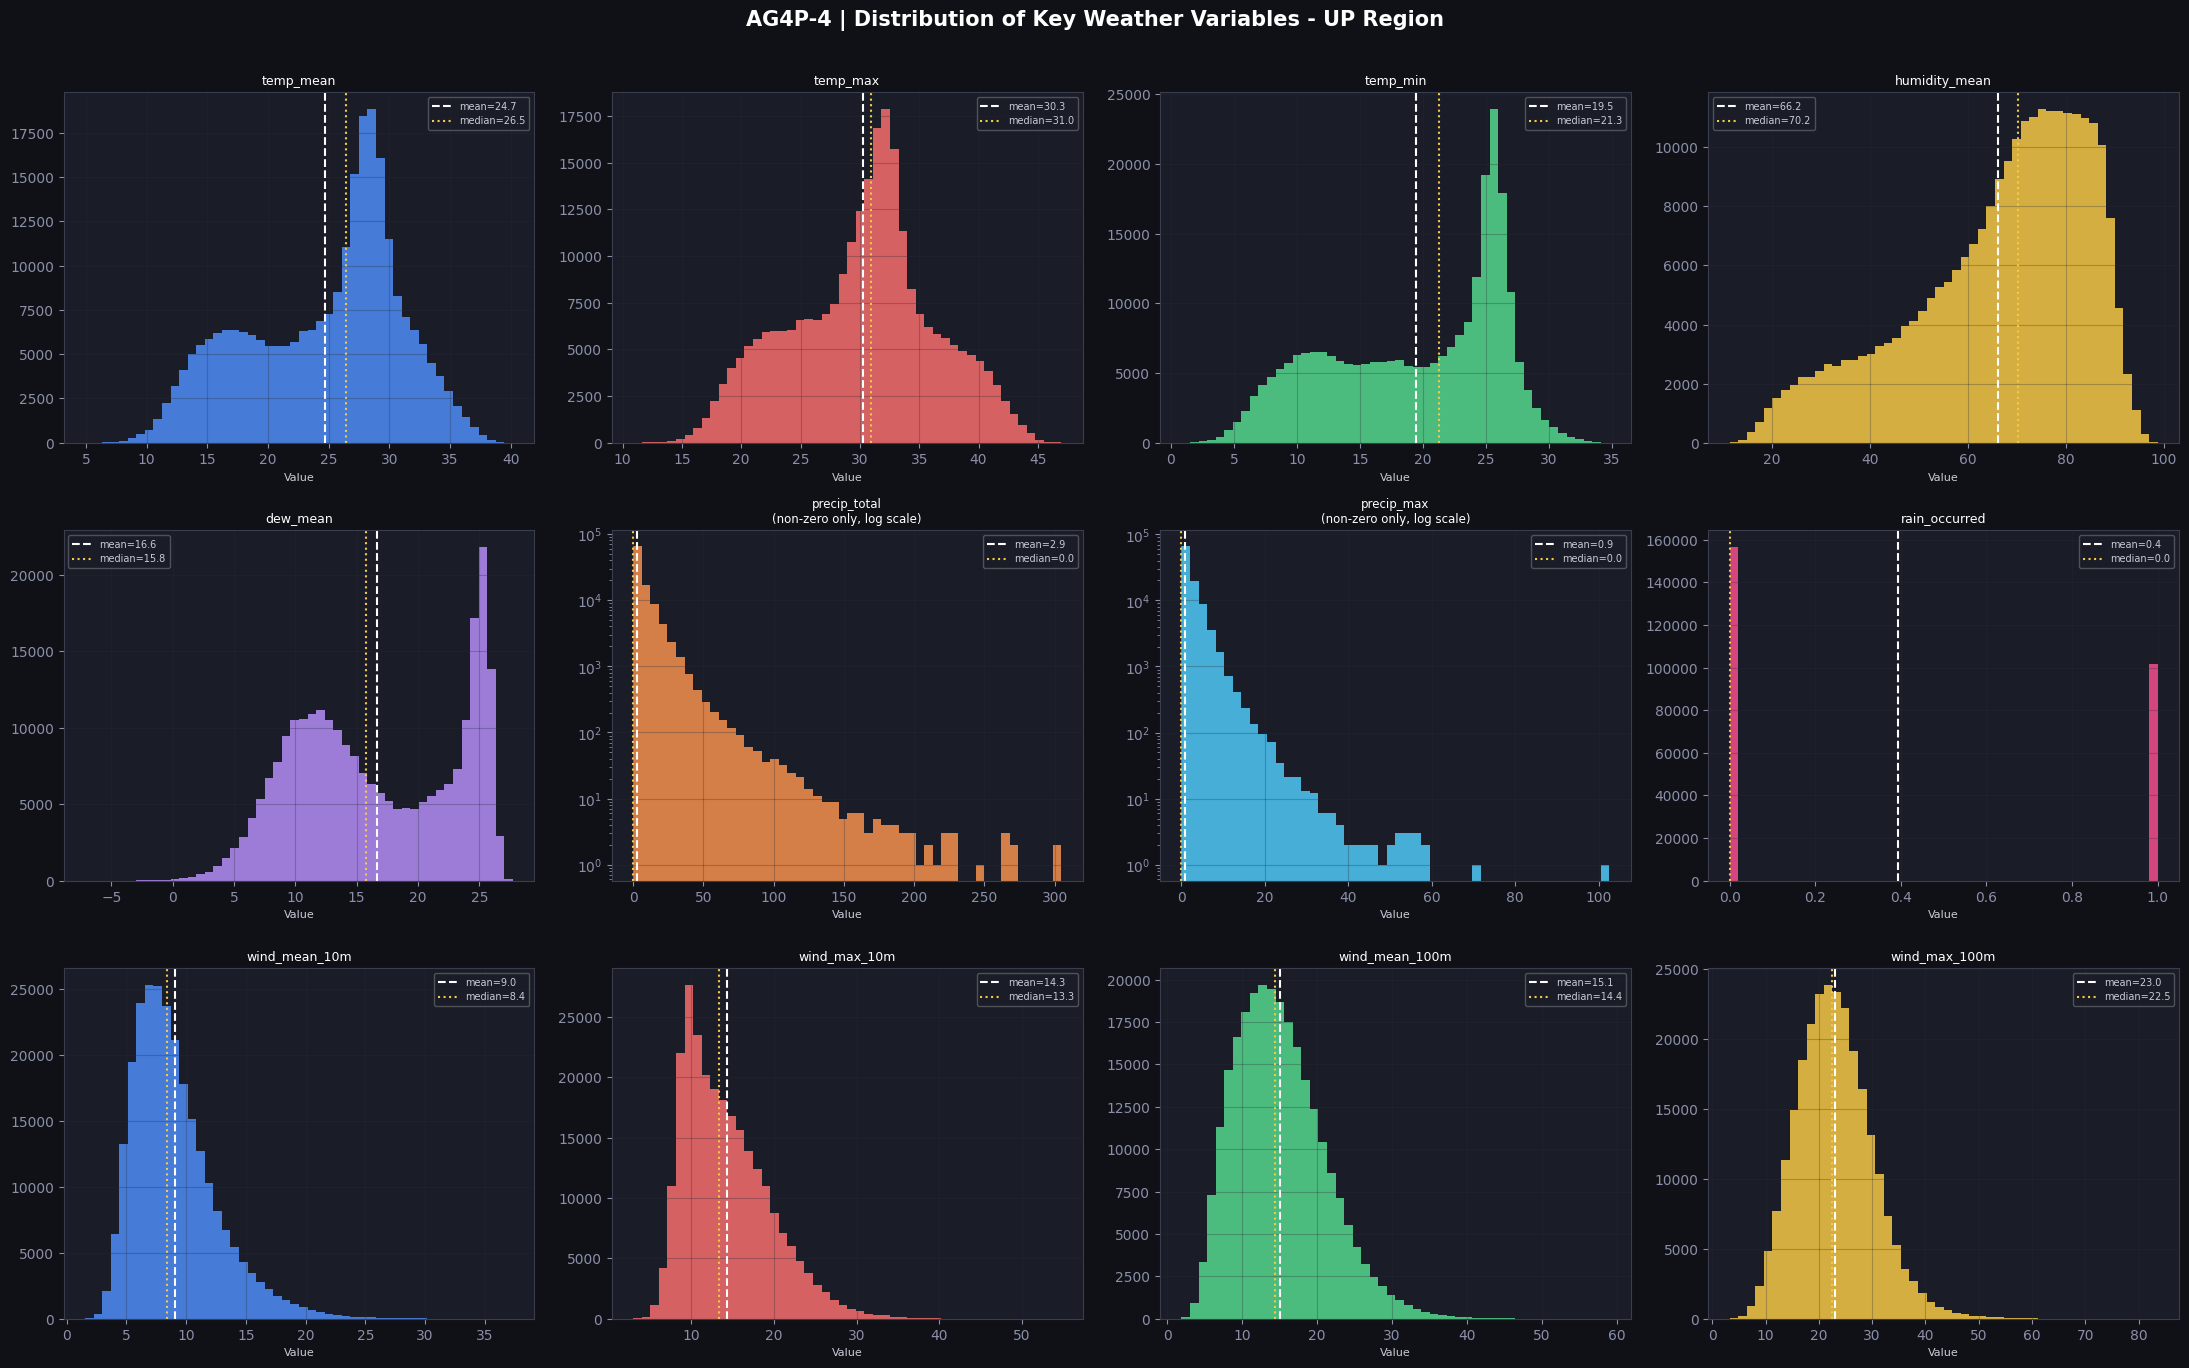

Saved: ag4p4_distributions.png


In [0]:
print("=" * 60)
print("AG4P-4 | STEP 3 - Distribution Histograms")
print("=" * 60)

plot_cols = ALL_NUMERIC[:12]
n_cols    = 4
n_rows    = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4.5))
fig.suptitle('AG4P-4 | Distribution of Key Weather Variables - UP Region',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for ax, col, color in zip(axes.flat, plot_cols, ACCENT * 4):
    data = df[col].dropna()

    if 'precip' in col and (data > 0).sum() > 0:
        data_plot = data[data > 0]
        ax.hist(data_plot, bins=50, color=color, alpha=0.85, edgecolor='none')
        ax.set_yscale('log')
        ax.set_title(col + '\n(non-zero only, log scale)', fontsize=8.5, color='white')
    else:
        ax.hist(data, bins=50, color=color, alpha=0.85, edgecolor='none')
        ax.set_title(col, fontsize=9, color='white')

    ax.axvline(data.mean(),   color='white',   lw=1.5, linestyle='--', label='mean=' + str(round(data.mean(), 1)))
    ax.axvline(data.median(), color='#f7c948', lw=1.5, linestyle=':',  label='median=' + str(round(data.median(), 1)))
    ax.legend(fontsize=7, framealpha=0.3)
    ax.set_xlabel('Value', fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes.flat[len(plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(SAVE + 'ag4p4_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved: ag4p4_distributions.png")

Outlier Detection

In [0]:
print("=" * 60)
print("AG4P-4 | STEP 4 - Outlier Detection (IQR Method)")
print("=" * 60)

outlier_focus = [c for c in [
    'temp_mean','temp_max','temp_min',
    'precip_total','precip_max',
    'wind_mean_100m','wind_max_100m',
    'pressure_mean'
] if c in df.columns]

outlier_report = []
for col in outlier_focus:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    out = df[(df[col] < lo) | (df[col] > hi)]
    pct = round(len(out) / len(df) * 100, 2)
    flag = 'REVIEW' if pct > 5 else 'OK'
    outlier_report.append({
        'column'        : col,
        'lower_fence'   : round(lo, 2),
        'upper_fence'   : round(hi, 2),
        'outlier_count' : len(out),
        'outlier_pct'   : pct,
        'flag'          : flag
    })
    print(col, "| outliers:", len(out), "(", pct, "%) |", flag)

out_df = pd.DataFrame(outlier_report)

AG4P-4 | STEP 4 - Outlier Detection (IQR Method)
temp_mean | outliers: 1 ( 0.0 %) | OK
temp_max | outliers: 180 ( 0.07 %) | OK
temp_min | outliers: 0 ( 0.0 %) | OK
precip_total | outliers: 48637 ( 18.84 %) | REVIEW
precip_max | outliers: 45113 ( 17.47 %) | REVIEW
wind_mean_100m | outliers: 3383 ( 1.31 %) | OK
wind_max_100m | outliers: 3305 ( 1.28 %) | OK
pressure_mean | outliers: 0 ( 0.0 %) | OK


Box Plots

AG4P-4 | STEP 5 - Outlier Box Plots


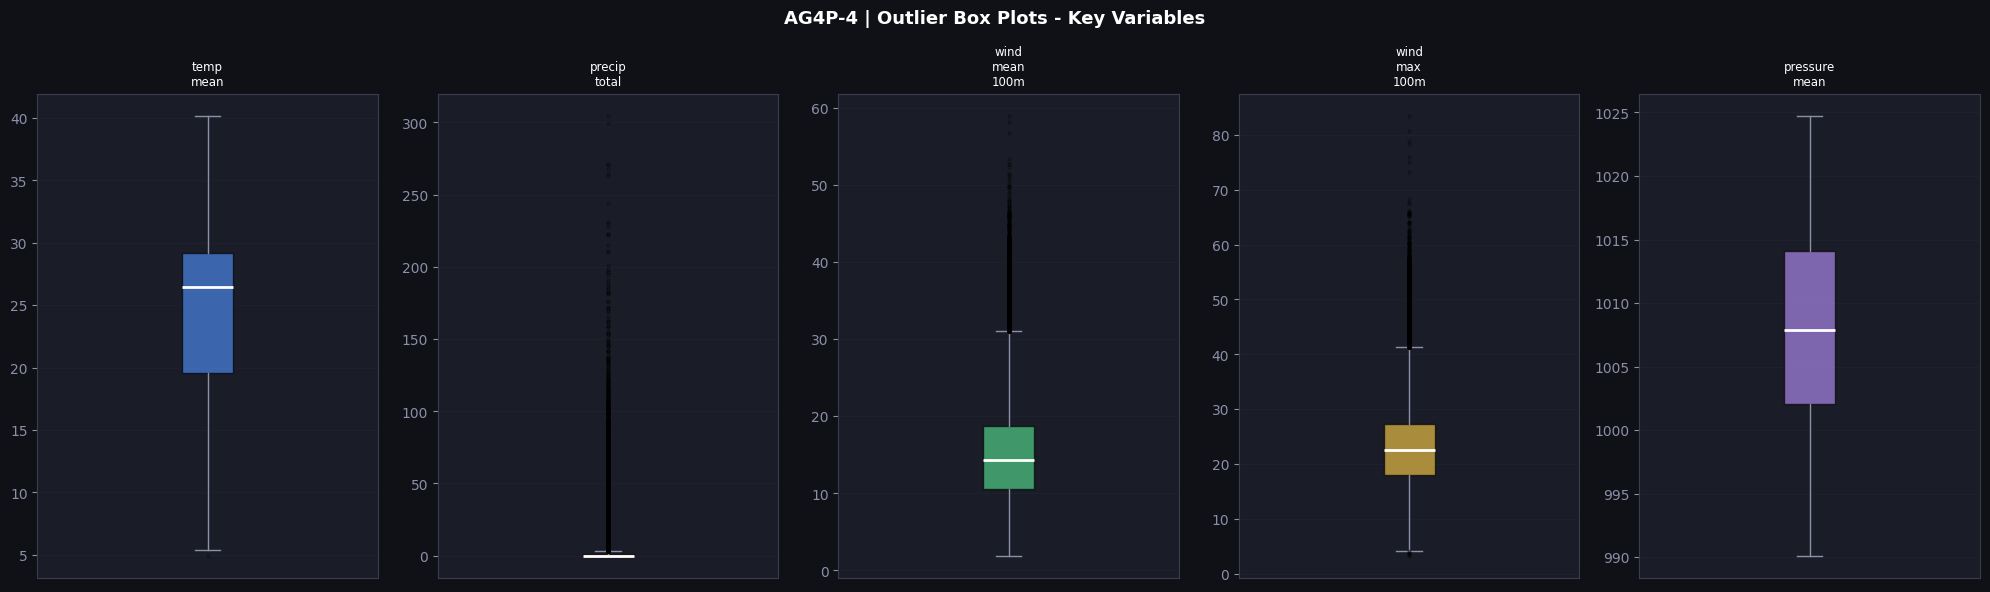

Saved: ag4p4_outlier_boxplots.png


In [0]:
print("=" * 60)
print("AG4P-4 | STEP 5 - Outlier Box Plots")
print("=" * 60)

box_cols = [c for c in [
    'temp_mean','precip_total',
    'wind_mean_100m','wind_max_100m','pressure_mean'
] if c in df.columns]

fig, axes = plt.subplots(1, len(box_cols), figsize=(20, 6))
fig.suptitle('AG4P-4 | Outlier Box Plots - Key Variables',
             fontsize=13, fontweight='bold', color='white')

for ax, col, color in zip(axes, box_cols, ACCENT):
    data = df[col].dropna()
    bp   = ax.boxplot(
        data,
        patch_artist = True,
        notch        = False,
        medianprops  = dict(color='white', lw=2),
        flierprops   = dict(marker='o', color=color, alpha=0.3, markersize=2),
        whiskerprops = dict(color='#8b8fa8'),
        capprops     = dict(color='#8b8fa8')
    )
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.65)
    ax.set_title(col.replace('_', '\n'), fontsize=8.5, color='white')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([])

plt.tight_layout()
plt.savefig(SAVE + 'ag4p4_outlier_boxplots.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved: ag4p4_outlier_boxplots.png")

Physical Consistency Checks

In [0]:
print("=" * 60)
print("AG4P-4 | STEP 6 - Physical Consistency Checks")
print("=" * 60)

# 1. wind_max >= wind_mean
if 'wind_max_100m' in df.columns and 'wind_mean_100m' in df.columns:
    v = (df['wind_max_100m'] < df['wind_mean_100m']).sum()
    print("wind_max_100m >= wind_mean_100m :", "OK" if v == 0 else str(v) + " violations")

# 2. temp_max >= temp_mean >= temp_min
if all(c in df.columns for c in ['temp_max','temp_mean','temp_min']):
    v1 = (df['temp_max'] < df['temp_mean']).sum()
    v2 = (df['temp_mean'] < df['temp_min']).sum()
    print("temp_max >= temp_mean           :", "OK" if v1 == 0 else str(v1) + " violations")
    print("temp_mean >= temp_min           :", "OK" if v2 == 0 else str(v2) + " violations")

# 3. precip_total >= precip_max
if 'precip_total' in df.columns and 'precip_max' in df.columns:
    v = (df['precip_total'] < df['precip_max']).sum()
    print("precip_total >= precip_max      :", "OK" if v == 0 else str(v) + " violations")

# 4. rain_occurred aligns with precip_total
if 'rain_occurred' in df.columns and 'precip_total' in df.columns:
    mismatch = ((df['precip_total'] > 0) != (df['rain_occurred'] == 1)).sum()
    print("rain_occurred aligned           :", "OK" if mismatch == 0 else str(mismatch) + " mismatches")

# 5. Zero inflation
if 'precip_total' in df.columns:
    zero_pct = round((df['precip_total'] == 0).mean() * 100, 1)
    print("Precipitation zero inflation    :", zero_pct, "% days have zero rain -- use binary for PS1")

AG4P-4 | STEP 6 - Physical Consistency Checks
wind_max_100m >= wind_mean_100m : OK
temp_max >= temp_mean           : OK
temp_mean >= temp_min           : OK
precip_total >= precip_max      : OK
rain_occurred aligned           : OK
Precipitation zero inflation    : 60.6 % days have zero rain -- use binary for PS1


Redundant Column Check

In [0]:
print("=" * 60)
print("AG4P-4 | STEP 7 - Redundant Column Detection")
print("=" * 60)

check_pairs = [
    ('temp_mean',     'dew_mean'),
    ('wind_mean_10m', 'wind_mean_100m'),
    ('wind_max_10m',  'wind_max_100m'),
    ('precip_total',  'rain_occurred'),
    ('pressure_mean', 'surface_pressure_mean'),
    ('cloud_mean',    'cloud_low_mean'),
]

print("  Pair                                        Correlation   Decision")
print("-" * 75)

for c1, c2 in check_pairs:
    if c1 in df.columns and c2 in df.columns:
        r = round(df[c1].corr(df[c2]), 3)
        if abs(r) > 0.98:
            decision = "DROP ONE -- near duplicate"
        elif abs(r) > 0.85:
            decision = "WATCH -- multicollinearity risk"
        else:
            decision = "OK -- both carry unique signal"
        print(" ", c1, "<->", c2, ":", r, "|", decision)

AG4P-4 | STEP 7 - Redundant Column Detection
  Pair                                        Correlation   Decision
---------------------------------------------------------------------------
  temp_mean <-> dew_mean : 0.585 | OK -- both carry unique signal
  wind_mean_10m <-> wind_mean_100m : 0.966 | WATCH -- multicollinearity risk
  wind_max_10m <-> wind_max_100m : 0.892 | WATCH -- multicollinearity risk
  precip_total <-> rain_occurred : 0.432 | OK -- both carry unique signal
  pressure_mean <-> surface_pressure_mean : 0.482 | OK -- both carry unique signal
  cloud_mean <-> cloud_low_mean : 0.824 | OK -- both carry unique signal
